In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = load_diabetes(as_frame=True)
X = data.data
y = data.target

X.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
linreg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linreg_pipeline.fit(X_train, y_train)
linreg_preds = linreg_pipeline.predict(X_test)

linreg_mae = mean_absolute_error(y_test, linreg_preds)
linreg_rmse = mean_squared_error(y_test, linreg_preds) ** 0.5
linreg_r2 = r2_score(y_test, linreg_preds)

print(f"LinearRegression MAE: {linreg_mae:.4f}")
print(f"LinearRegression RMSE: {linreg_rmse:.4f}")
print(f"Ridge MAE: {linreg_r2:.4f}")


In [ ]:
ridge_pipline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge()),
])

In [ ]:
ridge_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
}

In [ ]:
ridge_grid = GridSearchCV(
    estimator=ridge_pipline,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

ridge_grid.fit(X_train, y_train)

In [ ]:
print(ridge_grid.best_params_)
print(ridge_grid.best_score_)

In [ ]:
ridge_cv_mae = -ridge_grid.best_score_
ridge_cv_mae

In [ ]:
best_ridge = ridge_grid.best_estimator_

ridge_preds = best_ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = mean_squared_error(y_test, ridge_preds) ** 0.5
ridge_r2 = r2_score(y_test, ridge_preds)

print(f"Ridge MAE: {ridge_mae:.4f}")
print(f"Ridge RMSE: {ridge_rmse:.4f}")
print(f"Ridge R2: {ridge_r2:.4f}")

In [ ]:
lasso_pipline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso()),
])

In [ ]:
lasso_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
}

In [ ]:
lasso_grid = GridSearchCV(
    estimator=lasso_pipline,
    param_grid=lasso_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
lasso_grid.fit(X_train, y_train)

In [ ]:
print(lasso_grid.best_params_)
print(lasso_grid.best_score_)

lass_cv_mae = -lasso_grid.best_score_
lass_cv_mae

In [ ]:
best_lasso = lasso_grid.best_estimator_

lasso_preds = best_lasso.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_preds)
lasso_rmse = mean_squared_error(y_test, lasso_preds) ** 0.5
lasso_r2 = r2_score(y_test, lasso_preds)

print(f"Lasso MAE: {lasso_mae:.4f}")
print(f"Lasso RMSE: {lasso_rmse:.4f}")
print(f"Lasso R2: {lasso_r2:.4f}")

In [ ]:
results = pd.DataFrame([
    {
        "model": "LinearRegression",
        "MAE": linreg_mae,
        "RMSE": linreg_rmse,
        "R2": linreg_r2,
    },
    {
        "model": "Ridge",
        "MAE": ridge_mae,
        "RMSE": ridge_rmse,
        "R2": ridge_r2,
        "best_alpha": ridge_grid.best_params_["model__alpha"],
        "cv_mae": ridge_cv_mae
    },
    {
        "model": "Lasso",
        "MAE": lasso_mae,
        "RMSE": lasso_rmse,
        "R2": lasso_r2,
        "best_alpha": lasso_grid.best_params_["model__alpha"],
        "cv_mae": lass_cv_mae
    }
])

results.sort_values("MAE")

In [ ]:
ridge_results = pd.DataFrame(ridge_grid.cv_results_)

ridge_results[[
    "param_model__alpha",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].sort_values("rank_test_score", ascending=False)

In [ ]:
lasso_results = pd.DataFrame(lasso_grid.cv_results_)
lasso_results[[
    "param_model__alpha",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].sort_values("rank_test_score")

In [ ]:
ridge_coef = best_ridge.named_steps["model"].coef_
lasso_coef = best_lasso.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": X.columns,
    "ridge_coef": ridge_coef,
    "lasso_coef": lasso_coef,
})

coef_df

In [ ]:
coef_df.set_index("feature")[["ridge_coef", "lasso_coef"]].plot(kind="bar", figsize=(12, 5))

plt.title("Best Ridge vs Best Lasso Coefficient")
plt.ylabel("Coefficient value")
plt.show()

In [2]:
# Task A
data = load_diabetes(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [3]:
# Task B
linreg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linreg_pipeline.fit(X_train, y_train)
linreg_preds = linreg_pipeline.predict(X_test)

linreg_mae = mean_absolute_error(y_test, linreg_preds)
linreg_rmse = mean_squared_error(y_test, linreg_preds) ** 0.5
linreg_r2 = r2_score(y_test, linreg_preds)

print(f"Linear Regression MAE : {linreg_mae:.4f}")
print(f"Linear Regression RMSE: {linreg_rmse:.4f}")
print(f"Linear Regression R2  : {linreg_r2:.4f}")

Linear Regression MAE : 42.7941
Linear Regression RMSE: 53.8534
Linear Regression R2  : 0.4526


In [4]:
# Task C
ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

ridge_grid.fit(X_train, y_train)

ridge_cv_mae = -ridge_grid.best_score_

print(ridge_grid.best_params_)
print(f"Ridge CV MAE: {ridge_cv_mae:.4f}")

{'model__alpha': 10}
Ridge CV MAE: 45.4015


In [5]:
# Task D
best_ridge = ridge_grid.best_estimator_
ridge_preds = best_ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = mean_squared_error(y_test, ridge_preds) ** 0.5
ridge_r2 = r2_score(y_test, ridge_preds)

print(f"Ridge MAE : {ridge_mae:.4f}")
print(f"Ridge RMSE: {ridge_rmse:.4f}")
print(f"Ridge R2  : {ridge_r2:.4f}")

Ridge MAE : 42.8568
Ridge RMSE: 53.6263
Ridge R2  : 0.4572


In [6]:
# Task E
lasso_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])

lasso_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

lasso_grid.fit(X_train, y_train)

lasso_cv_mae = -lasso_grid.best_score_

print(lasso_grid.best_params_)
print(f"Lasso CV MAE: {lasso_cv_mae:.4f}")

best_lasso = lasso_grid.best_estimator_
lasso_preds = best_lasso.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_preds)
lasso_rmse = mean_squared_error(y_test, lasso_preds) ** 0.5
lasso_r2 = r2_score(y_test, lasso_preds)

print(f"Lasso MAE : {lasso_mae:.4f}")
print(f"Lasso RMSE: {lasso_rmse:.4f}")
print(f"Lasso R2  : {lasso_r2:.4f}")

{'model__alpha': 0.1}
Lasso CV MAE: 45.4899
Lasso MAE : 42.8052
Lasso RMSE: 53.7087
Lasso R2  : 0.4555


In [7]:
# Task F
results = pd.DataFrame([
    {
        "model": "LinearRegression",
        "MAE": linreg_mae,
        "RMSE": linreg_rmse,
        "R2": linreg_r2,
        "best_alpha": None,
        "cv_mae": None,
    },
    {
        "model": "Ridge",
        "MAE": ridge_mae,
        "RMSE": ridge_rmse,
        "R2": ridge_r2,
        "best_alpha": ridge_grid.best_params_["model__alpha"],
        "cv_mae": ridge_cv_mae,
    },
    {
        "model": "Lasso",
        "MAE": lasso_mae,
        "RMSE": lasso_rmse,
        "R2": lasso_r2,
        "best_alpha": lasso_grid.best_params_["model__alpha"],
        "cv_mae": lasso_cv_mae,
    }
])

results_sorted = results.sort_values("MAE")
results_sorted

,model,MAE,RMSE,R2,best_alpha,cv_mae
0,LinearRegression,42.794095,53.853446,0.452603,NaN,NaN
2,Lasso,42.805234,53.708698,0.455541,0.1,45.489854
1,Ridge,42.856825,53.626288,0.457211,10.0,45.401456


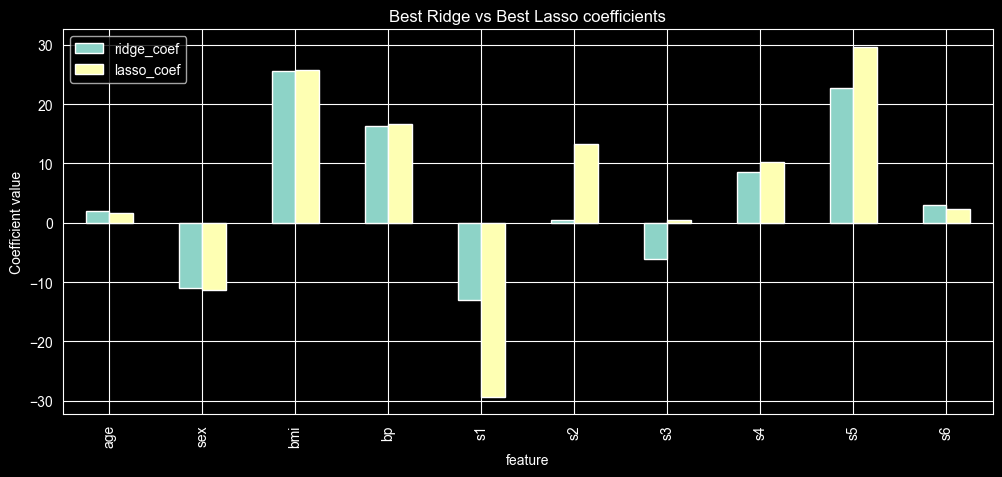

In [8]:
# Task G
ridge_coef = best_ridge.named_steps["model"].coef_
lasso_coef = best_lasso.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "ridge_coef": ridge_coef,
    "lasso_coef": lasso_coef,
})

coef_df

coef_df.set_index("feature")[["ridge_coef", "lasso_coef"]].plot(kind="bar", figsize=(12, 5))
plt.title("Best Ridge vs Best Lasso coefficients")
plt.ylabel("Coefficient value")
plt.show()

## Выводы

- Ridge и Lasso позволяют подобрать силу регуляризации через `alpha`.
- GridSearchCV перебирает значения `alpha` через cross-validation на train-части.
- `best_score_` при `neg_mean_absolute_error` возвращается отрицательным, поэтому мы переводим его в положительный MAE.
- После подбора гиперпараметров модель проверяется на test-наборе.
- Ridge уменьшает коэффициенты, а Lasso может занулять часть коэффициентов.
- Сравнение с LinearRegression нужно, чтобы понять, дала ли регуляризация реальную пользу.